In [10]:
from utils import get_match_df, analyze_strategies, get_best_leagues, get_best_strategies, compare_strategies

df = get_match_df()

df.tail()

/home/maicolnicolini/code/bet-master-analytics/src/strategies/utils.py:132: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  df_final = df_final[other_strategies_mask | dnb_mask]


,date,time,league,home_team,away_team,goal_home,goal_away,strategy,result,return,week
match_id,,,,,,,,,,,
d19441404,2026-03-23,20:30,La Liga 2,Castellón,Cultural Leonesa,1,1,Win x2 HT,True,0.8,12
d19636353,2026-03-23,02:15,Argentina,Independiente Rivadavia,Rosario Central,2,0,Goal HT,True,0.5,12
d19622006,2026-03-23,00:30,Brasile,Corinthians,Flamengo,1,1,Goal HT,True,0.5,12
d19678856,2026-03-25,18:00,Uruguay,Albion,Wanderers,2,1,Over 1.5 (M2-X),True,0.5,12
d19645505,2026-03-25,00:00,Colombia,Junior FC,Atlético Bucaramanga,2,0,Over 1.5 (M2-X),True,0.5,12


## Approccio 1: Scommetto tutti i mercati e tutti i campionati

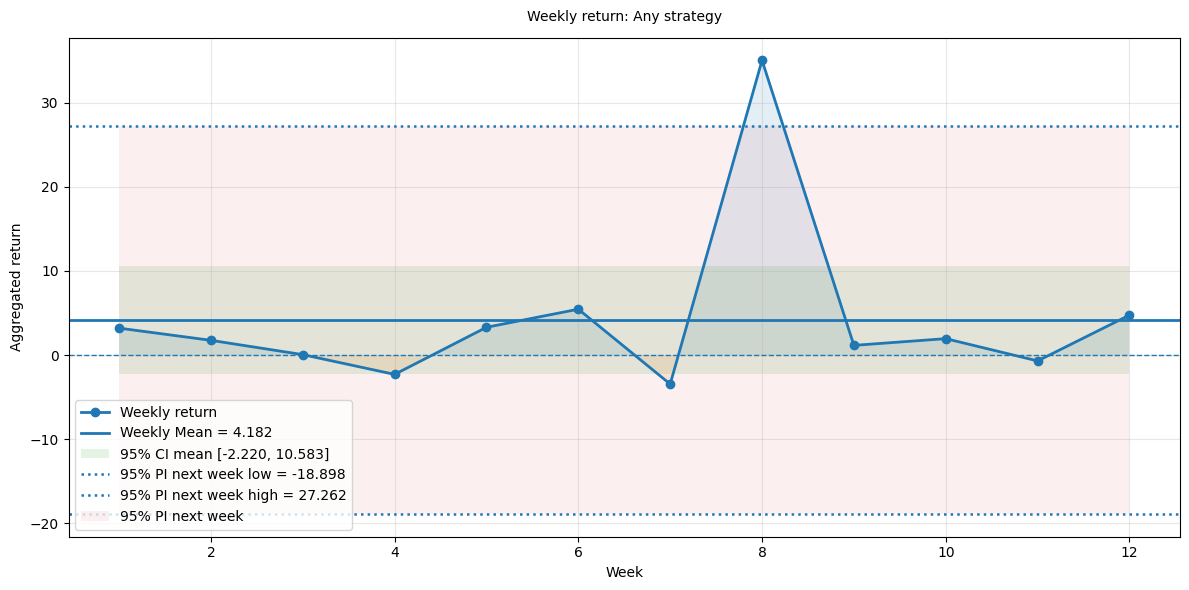

In [11]:
weekly_return, stats = analyze_strategies(df, print_pi=True)

In [12]:
weekly_return

week
1      3.20
2      1.75
3      0.05
4     -2.30
5      3.30
6      5.45
7     -3.45
8     35.03
9      1.15
10     1.95
11    -0.70
12     4.75
Name: return, dtype: float64

95% PI è la probabilità che il ritorno della prossima settimana sia compreso fra PI low e PI high
### Note:
1. Ritorno medio è positivo ma a estremo inferiore CI negativo -> non è detto che il vero valor medio del ritorno settimanale è > 0
2. 95% PI estremamente variabile

## Approccio 2: scommetto i mercati che si comportano meglio su tutti i campionati

In [13]:
strategy_df = get_best_strategies(df)
strategy_df

,weekly_mean_return,weekly_std_return,weekly_counts,total_counts,accuracy
Over 1.5 (M2-X),0.83,1.94,7.50,90,0.79
Goal HT,0.46,1.76,5.42,65,0.82
Win x2 HT,0.30,1.61,2.00,24,0.64
Multigoal 1-2 Home,0.28,1.27,1.00,12,0.79
DNB 1,0.19,2.24,7.25,87,0.72


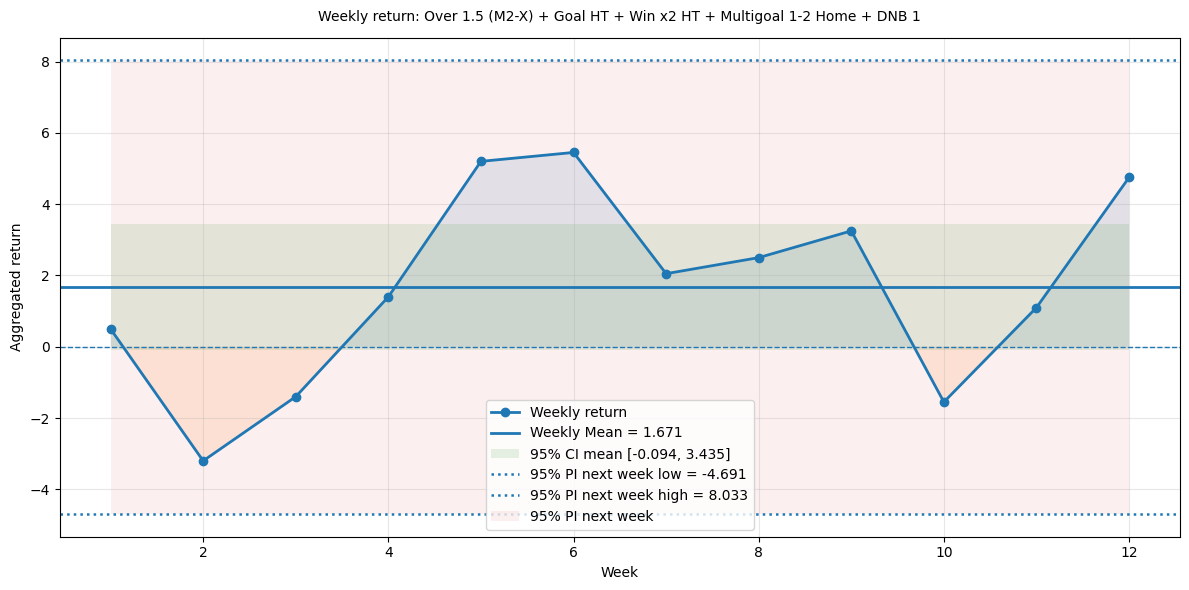

In [14]:
# Tolgo mercati con ritorno medio settimanale negativo e analizzo le strategie
best_strategies = strategy_df[strategy_df["weekly_mean_return"] > 0].index.to_list()
weekly_return, stats = analyze_strategies(df, strategies=best_strategies, print_pi=True)

In [15]:
weekly_return

week
1     0.50
2    -3.20
3    -1.40
4     1.40
5     5.20
6     5.45
7     2.05
8     2.50
9     3.25
10   -1.55
11    1.10
12    4.75
Name: return, dtype: float64

### Note:
- Valor medio leggermente più alto ma meno confidente (CI mean)
- Intervallo PI maggiore -> più volatile
- Andando a vedere sopra, BTTS è quello che porta più ritorno ma è quello più volatile (ha performato particolarmente bene in week 7), provo a toglierlo

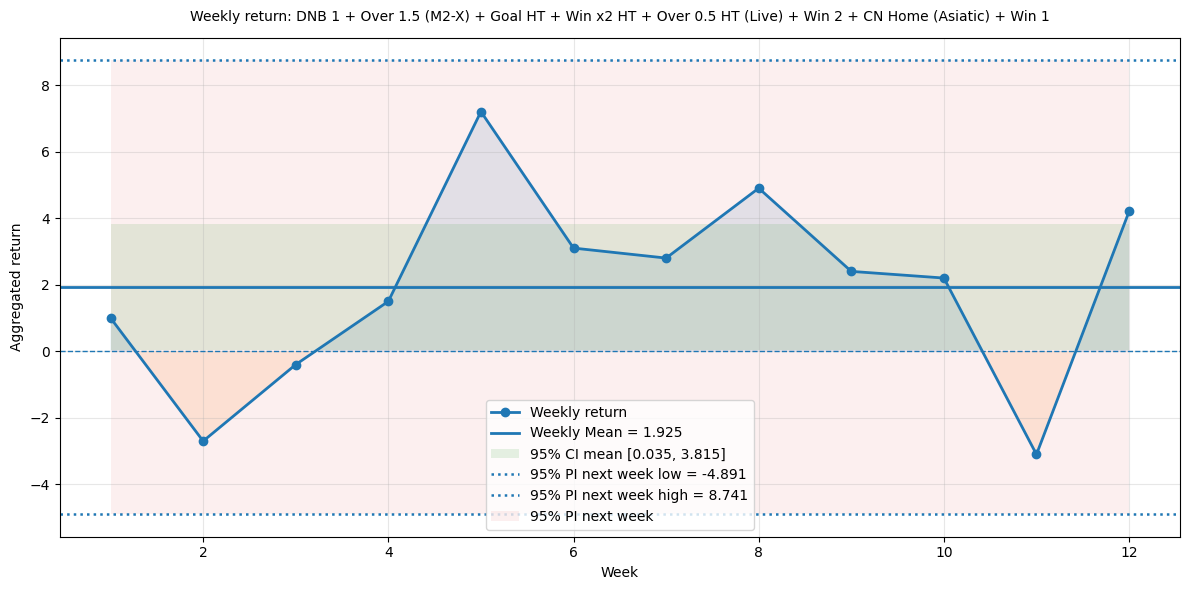

In [16]:
weekly_return, stats = analyze_strategies(df, strategies=['DNB 1', 'Over 1.5 (M2-X)', 'Goal HT', 'Win x2 HT', 'Over 0.5 HT (Live)', 'Win 2', 'CN Home (Asiatic)', 'Win 1'], print_pi=True)

In [17]:
weekly_return

week
1     1.00
2    -2.70
3    -0.40
4     1.50
5     7.20
6     3.10
7     2.80
8     4.90
9     2.40
10    2.20
11   -3.10
12    4.20
Name: return, dtype: float64

### Note:
- ritorno medio minore ma CI low > 0 -> al 95% il ritorno medio settimanale è positivo
- PI molto meno variabile

## Approccio 3: scommetto solo sui campionati migliori

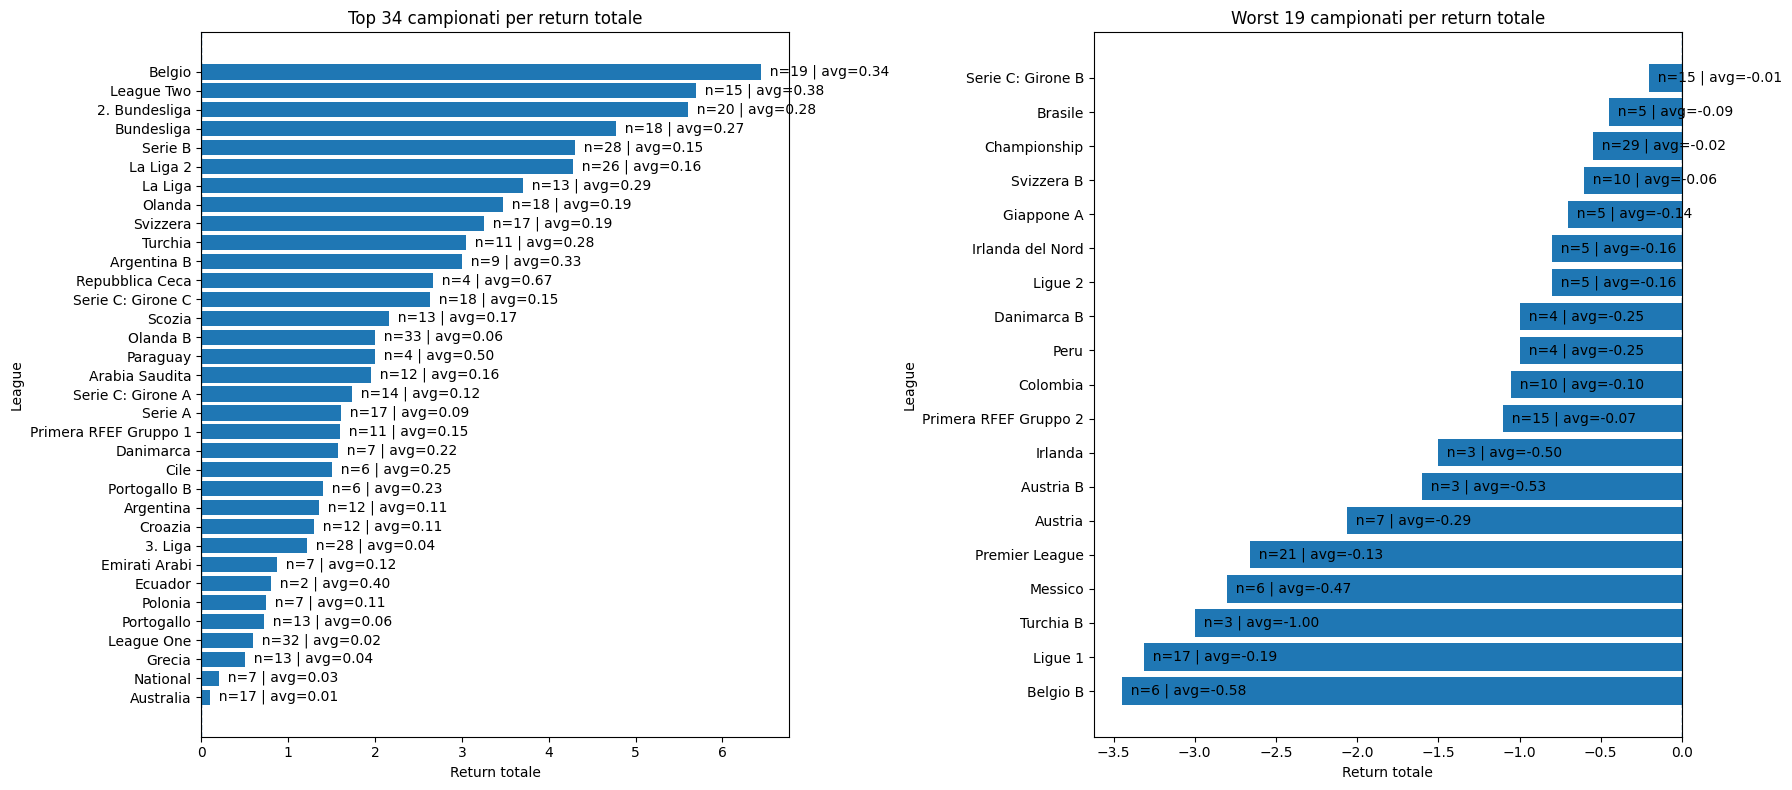

In [18]:
best_leagues = get_best_leagues(df)

In [19]:
threshold = best_leagues["n_matches"].quantile(q=0.1)
print(f"Threshold: {threshold}")
league_list = list(best_leagues[best_leagues["n_matches"] > threshold].index)

Threshold: 6.0


In [20]:
# Vedo quali sono le migliori scommesse per i campionati con ritorno positivo (considero solo campionati grafico a sx)
get_best_strategies(df, leagues=league_list)

,weekly_mean_return,weekly_std_return,weekly_counts,total_counts,accuracy
Win x2 HT,0.82,1.19,1.33,16,0.87
Over 1.5 (M2-X),0.72,1.09,4.58,55,0.82
Goal HT,0.67,1.34,3.58,43,0.86
Multigoal 1-2 Home,-0.07,0.85,0.42,5,0.60


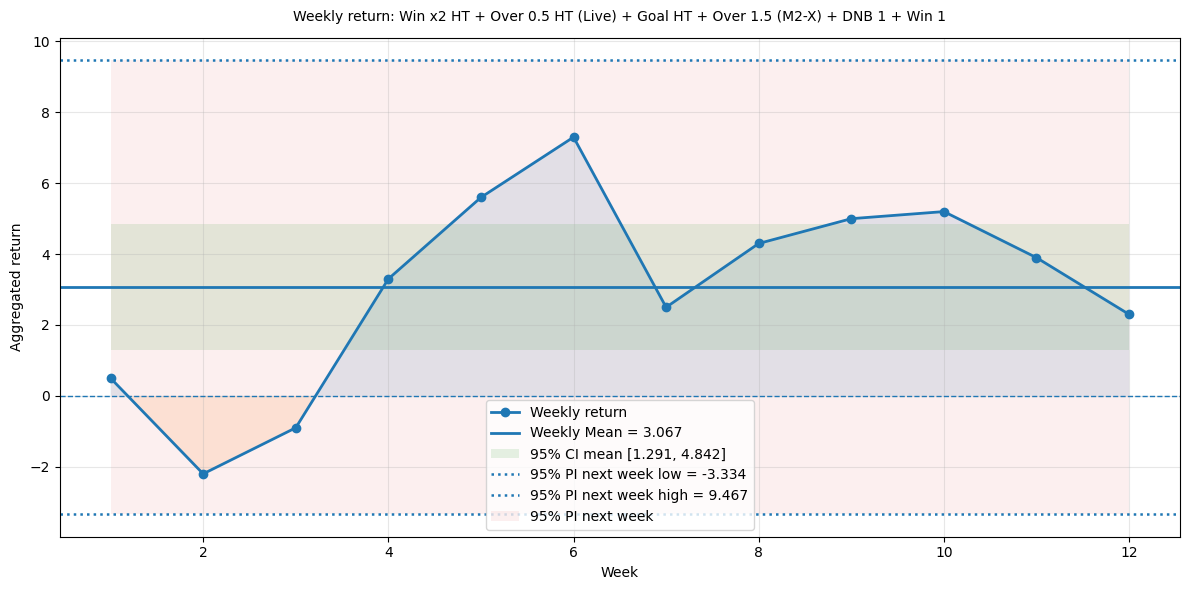

In [21]:
# Prendo le strategie migliori togliendo CN Home perchè ha ritorno negativo e BTTS per alta volatilità
best_strategies = ['Win x2 HT', 'Over 0.5 HT (Live)', 'Goal HT', 'Over 1.5 (M2-X)', 'DNB 1', 'Win 1']

weekly_return, stats_1 = analyze_strategies(df, strategies=best_strategies, leagues=league_list, print_pi=True)

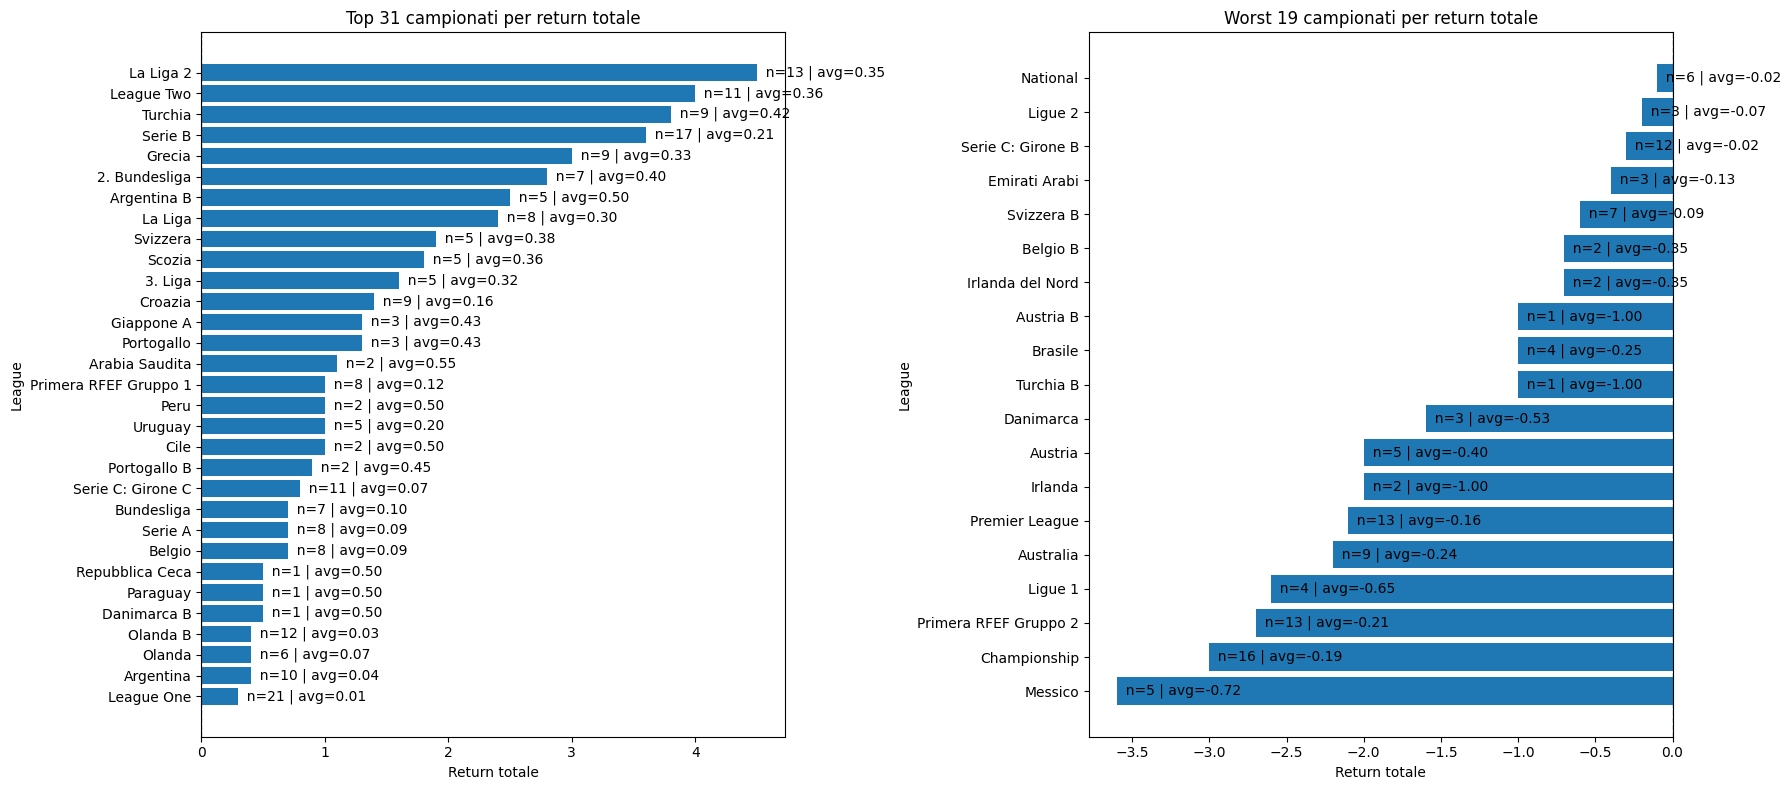

Threshold: 2.0


In [22]:
# Find the best leageus for the best strategies 
best_leagues = get_best_leagues(df, strategies=best_strategies)
threshold = best_leagues["n_matches"].quantile(q=0.1)
league_list = list(best_leagues[best_leagues["n_matches"] > threshold].index)

print(f"Threshold: {threshold}")

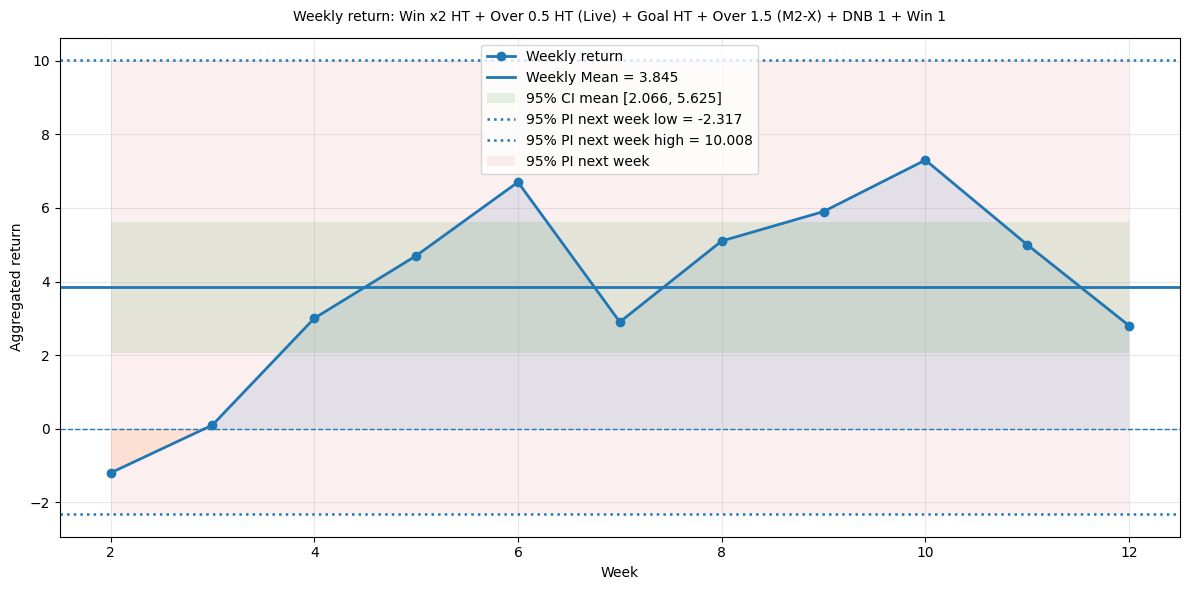

In [23]:
weekly_return, stats_2 = analyze_strategies(df, strategies=best_strategies, leagues=league_list, print_pi=True)

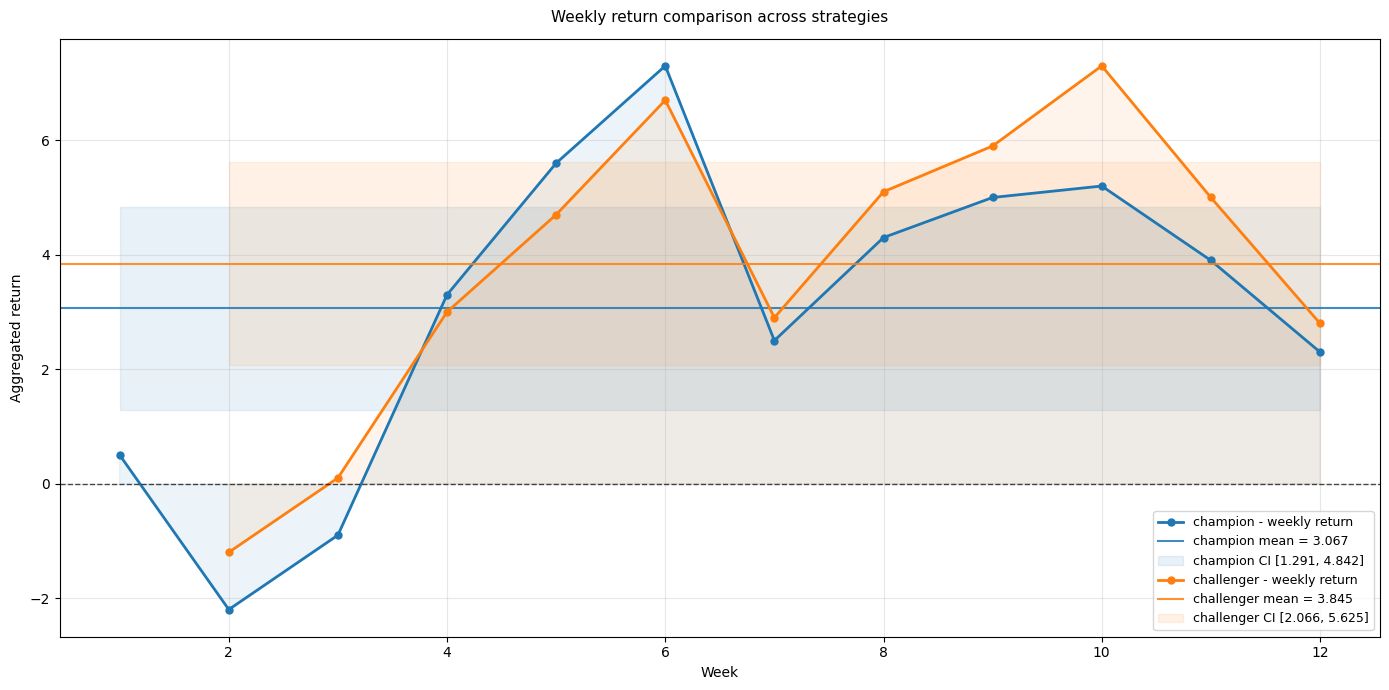

In [24]:
strategies_to_compare = {"champion": stats_1, "challenger": stats_2}

aggregated_data, summary_df = compare_strategies(
    df=df,
    strategies=strategies_to_compare,
    show_ci=True,
    show_pi=False
)

In [44]:
summary_df

,label,strategy,leagues,n_weeks,expected_bets_per_week,mean_weekly_agg_return,std_weekly_agg_return,sem,ci_low,ci_high,pi_low,pi_high
0,champion,"[Win x2 HT, Over 0.5 HT (Live), Goal HT, Over ...","[Belgio, League Two, 2. Bundesliga, Bundesliga...",11,21,3.23,2.96,0.89,1.24,5.22,-3.66,10.12
1,challenger,"[Win x2 HT, Over 0.5 HT (Live), Goal HT, Over ...","[League Two, Turchia, La Liga 2, Serie B, Grec...",10,19,4.46,3.06,0.97,2.27,6.65,-2.80,11.72


In [49]:
summary_df.iloc[1]['strategy']

['Win x2 HT',
 'Over 0.5 HT (Live)',
 'Goal HT',
 'Over 1.5 (M2-X)',
 'DNB 1',
 'Win 1']

### Note:
- Ritorno medio più alto del precedente ma ancora minore del primo
- Confidenza molto più alta sia del primo che del secondo (CI low 1.5 vuol dire che il valor medio sul lungo periodo è almeno 1.53 al 95% di confidenza)
- Variabilità sulla settimana (PI) maggiore di prima ma più spostato verso l'alto